In [2]:
!pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00


In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_bloch_vector
import numpy as np
import matplotlib.pyplot as plt
print('Environment ready ✓')

Environment ready ✓


In [ ]:
# North pole: |0⟩
qc0 = QuantumCircuit(1)
sv0 = Statevector.from_instruction(qc0)
print('|0⟩ state on Bloch sphere:')
plot_bloch_multivector(sv0)
plt.show()
# South pole: |1⟩
qc1 = QuantumCircuit(1)
qc1.x(0)
sv1 = Statevector.from_instruction(qc1)
print('|1⟩ state on Bloch sphere:')
plot_bloch_multivector(sv1)
plt.show()

|0⟩ state on Bloch sphere:
|1⟩ state on Bloch sphere:


In [ ]:
# H|0⟩ = |+⟩ (moves to +X axis)
qc_h = QuantumCircuit(1)
qc_h.h(0)
sv_plus = Statevector.from_instruction(qc_h)

print('|+⟩ = H|0⟩ — should point along +X axis:')
plot_bloch_multivector(sv_plus)
plt.show()

|+⟩ = H|0⟩ — should point along +X axis:


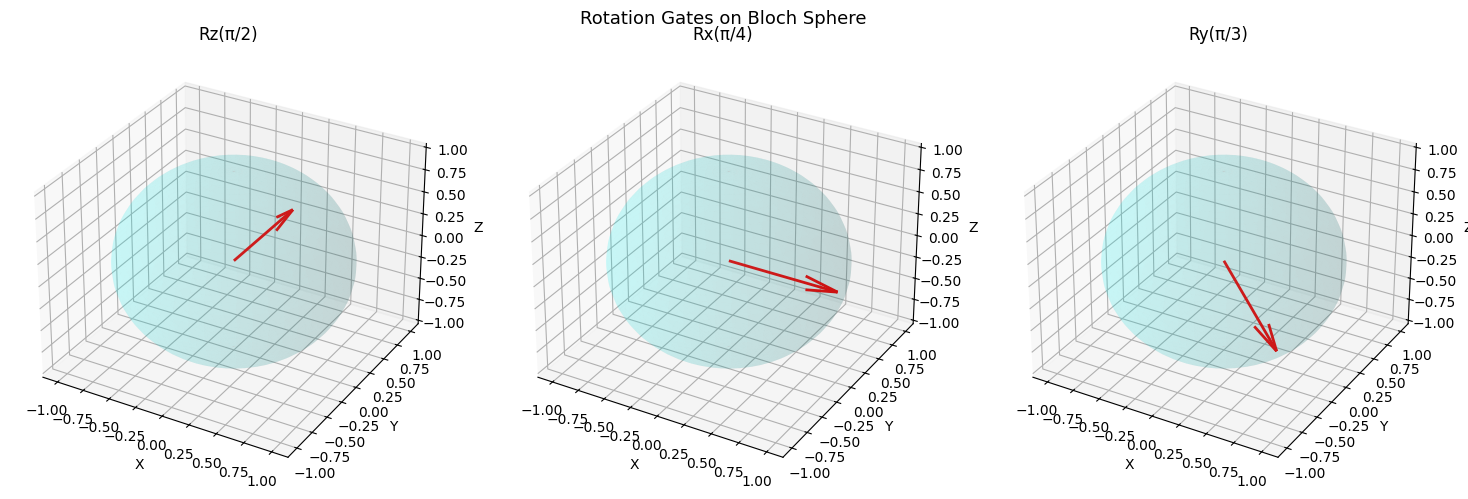

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': '3d'})

rotations = [
    ('Rz(π/2)', lambda qc: qc.rz(np.pi/2, 0)),
    ('Rx(π/4)', lambda qc: qc.rx(np.pi/4, 0)),
    ('Ry(π/3)', lambda qc: qc.ry(np.pi/3, 0)),
]

for i, (label, gate_fn) in enumerate(rotations):
    qc = QuantumCircuit(1)
    qc.h(0)       # start at |+⟩
    gate_fn(qc)   # apply rotation
    sv = Statevector.from_instruction(qc)
    # Bloch vector
    bv = sv.data
    x = 2 * (bv[0].real * bv[1].real + bv[0].imag * bv[1].imag)
    y = 2 * (bv[0].real * bv[1].imag - bv[0].imag * bv[1].real)
    z = abs(bv[0])**2 - abs(bv[1])**2
    ax = axes[i]
    ax.quiver(0,0,0, x, y, z, length=1, normalize=True, color='red', linewidth=2)
    u = np.linspace(0, 2*np.pi, 50)
    v = np.linspace(0, np.pi, 50)
    ax.plot_surface(np.outer(np.cos(u), np.sin(v)),
                    np.outer(np.sin(u), np.sin(v)),
                    np.outer(np.ones(50), np.cos(v)),
                    alpha=0.1, color='cyan')
    ax.set_title(label)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.suptitle('Rotation Gates on Bloch Sphere', fontsize=13)
plt.tight_layout()
plt.show()

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


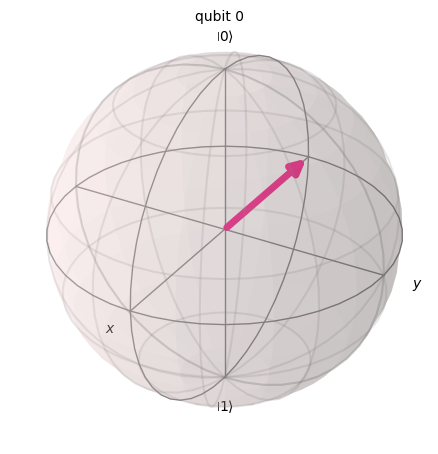

In [18]:
qc_minus = QuantumCircuit(1)
qc_minus.x(0)
qc_minus.h(0)
sv_minus = Statevector.from_instruction(qc_minus)
print(sv_minus)
plot_bloch_multivector(sv_minus)


|−⟩:
θ = π/2
φ = π

|i⟩:
θ = π/2
φ = π/2

Statevector([0.85355339+0.35355339j, 0.14644661-0.35355339j],
            dims=(2,))


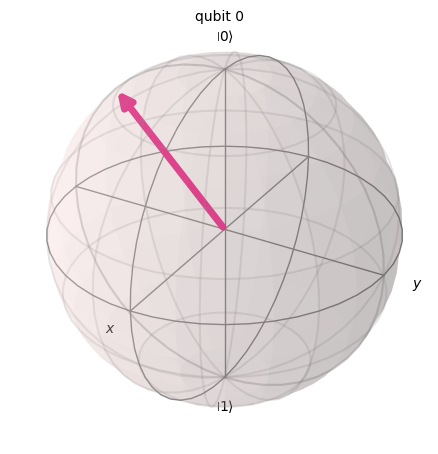

In [16]:
qc_htH = QuantumCircuit(1)
qc_htH.h(0)
qc_htH.t(0)
qc_htH.h(0)
sv_htH = Statevector.from_instruction(qc_htH)
print(sv_htH)
plot_bloch_multivector(sv_htH)


Applying the full sequence H-T-H to |0⟩ gives a different state. The first H creates a superposition, the T gate adds a phase to the |1⟩ part, and the final H changes that phase difference into a new Bloch sphere direction.

Key Takeaways
The Bloch sphere represents all pure single-qubit states as points on a unit sphere
Quantum gates are rotations around the X, Y, or Z axis
 = North Pole,
 = South Pole,
 on the equator
The global phase is unobservable — only the relative phase φ matters

📝 TODO Checklist
Complete Exercise 1: |-⟩ and |i⟩ on Bloch sphere
Complete Exercise 2: H-T-H sequence analysis
Plot all 6 cardinal states (+X,-X,+Y,-Y,+Z,-Z) in one figure

code is below.

Explain why the Bloch sphere only represents SINGLE qubit states

The Bloch sphere only represents single-qubit states because a single qubit has only two independent parameters, which can be shown as a point on the surface of a sphere. When two or more qubits are combined, the number of parameters increases significantly, especially if the qubits are entangled. These extra degrees of freedom cannot be represented in the two-dimensional geometry of a Bloch sphere. As a result, the Bloch sphere is only suitable for visualizing individual qubits, not multi-qubit quantum states.


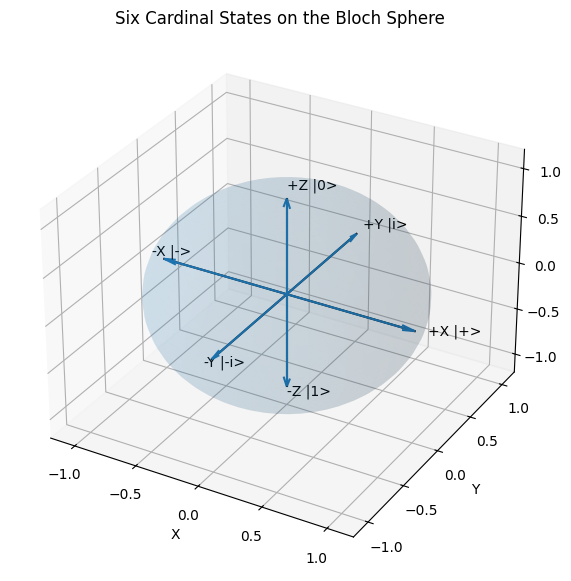

In [11]:



states = {
    "+X |+>":  [1, 0, 0],
    "-X |->":  [-1, 0, 0],
    "+Y |i>":  [0, 1, 0],
    "-Y |-i>": [0, -1, 0],
    "+Z |0>":  [0, 0, 1],
    "-Z |1>":  [0, 0, -1],
}

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")


u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones(len(u)), np.cos(v))

ax.plot_surface(x, y, z, alpha=0.1)


ax.plot([-1, 1], [0, 0], [0, 0], color="black")
ax.plot([0, 0], [-1, 1], [0, 0], color="black")
ax.plot([0, 0], [0, 0], [-1, 1], color="black")


for label, vector in states.items():
    ax.quiver(
        0, 0, 0,
        vector[0], vector[1], vector[2],
        arrow_length_ratio=0.1
    )

    ax.text(
        1.1 * vector[0],
        1.1 * vector[1],
        1.1 * vector[2],
        label
    )

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Six Cardinal States on the Bloch Sphere")

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_zlim([-1.2, 1.2])

plt.show()